
<font size="5">**Simple Linear Regression**</font>


**IMPORT LIBRARIES AND DATASETS**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("IceCreamData.csv")

In [3]:
dataset

,Temperature,Revenue
0,24.566884,534.799028
1,26.005191,625.190122
2,27.790554,660.632289
3,20.595335,487.706960
4,11.503498,316.240194
...,...,...
495,22.274899,524.746364
496,32.893092,755.818399
497,12.588157,306.090719
498,22.362402,566.217304


In [4]:
dataset.head()

,Temperature,Revenue
0,24.566884,534.799028
1,26.005191,625.190122
2,27.790554,660.632289
3,20.595335,487.706960
4,11.503498,316.240194


In [5]:
dataset.tail()

,Temperature,Revenue
495,22.274899,524.746364
496,32.893092,755.818399
497,12.588157,306.090719
498,22.362402,566.217304
499,28.957736,655.660388


In [6]:
dataset.describe()

,Temperature,Revenue
count,500.000000,500.000000
mean,22.232225,521.570777
std,8.096388,175.404751
min,0.000000,10.000000
25%,17.122258,405.558681
50%,22.392791,529.368565
75%,27.740674,642.257922
max,45.000000,1000.000000


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


**PERFORM DATA VISUALIZATION**

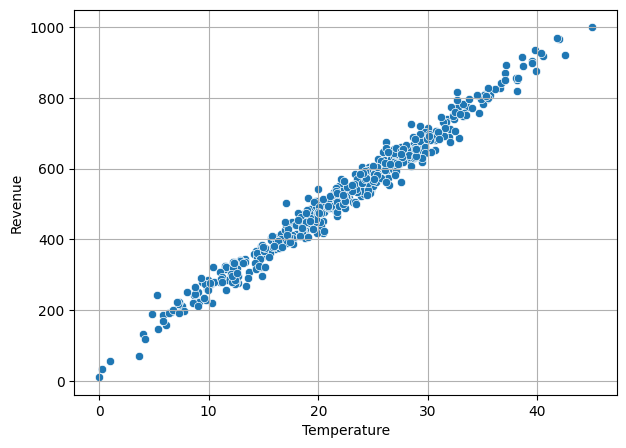

In [32]:
plt.figure(figsize = (7,5))
sns.scatterplot(x= 'Temperature', y='Revenue', data= dataset)
plt.grid()

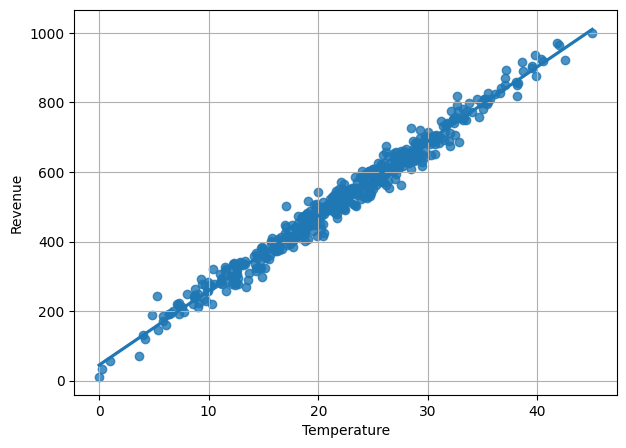

In [33]:
plt.figure(figsize = (7,5))
sns.regplot(x= 'Temperature', y='Revenue', data= dataset)
plt.grid()

**SPLITTING THE DATASET INTO THE TRAINING SET AND TEST SET**

In [16]:
X = dataset['Temperature']
y = dataset['Revenue']

X = np.array(X)
y = np.array(y)

X = X.reshape(-1,1)
y = y.reshape(-1,1)

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2)

**TRAIN A SIMPLE LINEAR REGRESSION MODEL IN SCIKIT LEARN**

In [21]:
from sklearn.linear_model import LinearRegression

SimpleLinearRegression = LinearRegression(fit_intercept = True)
SimpleLinearRegression.fit(X_train, y_train)

LinearRegression()

In [22]:
print('Linear Model Coeff(m)', SimpleLinearRegression.coef_)
print('Linear Model Coeff(b)', SimpleLinearRegression.intercept_)

Linear Model Coeff(m) [[21.46447525]]
Linear Model Coeff(b) [44.63765856]


**EVALUATE TRAINED SIMPLE LINEAR REGRESSION MODEL IN SCIKIT LEARN**

Text(0.5, 1.0, 'Revenue Gerated vs. Temperature')

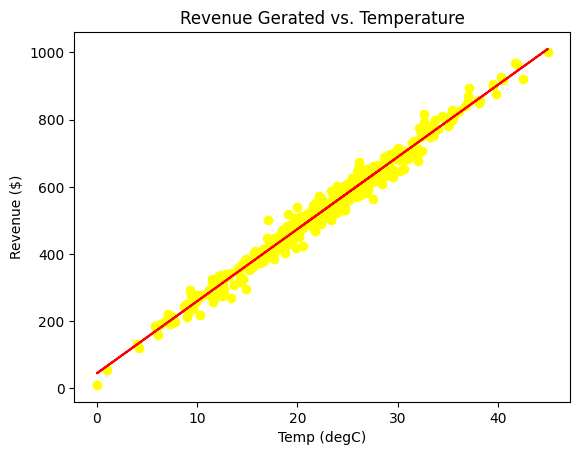

In [24]:
plt.scatter(X_train, y_train, color = 'yellow')
plt.plot(X_train, SimpleLinearRegression.predict(X_train), color = 'r')
plt.ylabel('Revenue ($)')
plt.xlabel("Temp (degC)")
plt.title('Revenue Gerated vs. Temperature')

In [25]:
accuracy_LinearRegression = SimpleLinearRegression.score(X_test, y_test)
accuracy_LinearRegression

0.9761278599780365

Text(0.5, 1.0, 'Revenue Gerated vs. Temperature')

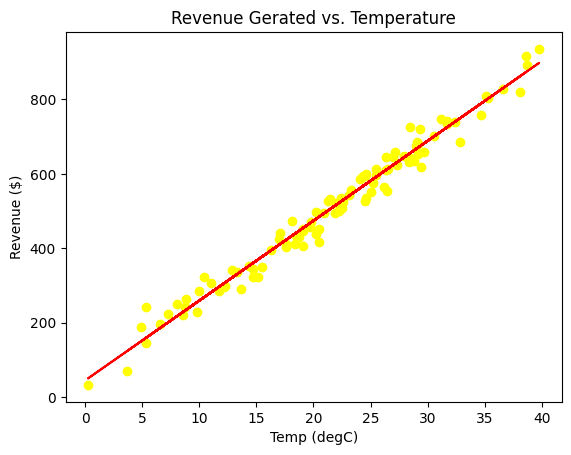

In [26]:
plt.scatter(X_test, y_test, color = 'yellow')
plt.plot(X_test, SimpleLinearRegression.predict(X_test), color = 'r')
plt.ylabel('Revenue ($)')
plt.xlabel("Temp (degC)")
plt.title('Revenue Gerated vs. Temperature')

**USE THE TRAINED MODEL TO GENERATE PREDICTIONS**

In [28]:
Temp = np.array([20])
Temp = Temp.reshape(-1,1)

Revenue = SimpleLinearRegression.predict(Temp)
print('Revenue Predictions =', Revenue)

Revenue Predictions = [[473.92716348]]


**COMPARING THE TEST SET WITH PREDICTED VALUES**

In [31]:
y_pred = SimpleLinearRegression.predict(X_test)
comparison_df = pd.DataFrame({
    'Actual Values': y_test.flatten(),
    'Predicted Values': y_pred.flatten()
})
print(comparison_df)

    Actual Values  Predicted Values
0      441.508733        411.479376
1      451.450784        484.092613
2      406.516091        453.892032
3      242.236208        232.571029
4      297.499120        306.712111
..            ...               ...
95     644.488633        622.538724
96     543.599593        539.836322
97     679.317791        671.079327
98     520.853456        517.068061
99     586.150568        561.966201

[100 rows x 2 columns]
